In [17]:
import pandas as pd

def processingdata():
    df = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")
    dictn = {}
    cols = df.select_dtypes(include=["object"]).columns

    for col in df.columns:
        if col in cols:
            df[col] = df[col].fillna(df[col].mode()[0])
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            dictn[col] = mpp
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].mean())

    return df, dictn


In [18]:
# Load the dataset after cleaning and encoding via the custom preprocessing function
processed_df, label_maps = processingdata()

# Import necessary modules for data preparation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Define the input features (X) and the target label (y)
# Dropping 'id' since it's just an identifier and 'stroke' is the target
features = processed_df.drop(columns=['id', 'stroke'])
target = processed_df['stroke']

# Standardize the feature values to ensure all features are on the same scale
# This helps models like logistic regression converge faster
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split the dataset into training and testing subsets
# Using 80% of the data for training and 20% for testing
# Setting a fixed random_state ensures reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, target, test_size=0.2, random_state=42
)


In [19]:
import numpy as np

class MyLogisticModel:
    def __init__(self, lr=0.01, iterations=1000):
        # Set initial learning rate and the total number of update cycles (epochs)
        self.lr = lr
        self.iterations = iterations
        self.coefficients = None  # Feature weights initialized later
        self.intercept = None     # Scalar bias term

    def _sigmoid(self, z):
        # This helper function applies the sigmoid transformation
        # It maps any real-valued number into the (0, 1) interval
        return 1 / (1 + np.exp(-z))

    def train(self, X, y):
        # Get the dimensions of the input data
        num_samples, num_features = X.shape

        # Initialize model parameters with zeros
        self.coefficients = np.zeros(num_features)
        self.intercept = 0

        # Compute weights to handle imbalanced class distributions
        weight_0 = len(y) / (2 * np.sum(y == 0))
        weight_1 = len(y) / (2 * np.sum(y == 1))
        class_weights = np.where(y == 1, weight_1, weight_0)

        # Begin the training loop using gradient descent
        for _ in range(self.iterations):
            # Compute linear output (dot product of features and weights + bias)
            linear_pred = np.dot(X, self.coefficients) + self.intercept

            # Use sigmoid to get probability-like output
            predictions = self._sigmoid(linear_pred)

            # Calculate the difference between predictions and actual labels
            errors = predictions - y

            # Apply class-specific weights to the errors
            weighted_errors = class_weights * errors

            # Compute gradient of loss with respect to weights and bias
            dw = (1 / num_samples) * np.dot(X.T, weighted_errors)
            db = (1 / num_samples) * np.sum(weighted_errors)

            # Update parameters in the direction of minimizing the loss
            self.coefficients -= self.lr * dw
            self.intercept -= self.lr * db

    def classify(self, X):
        # Compute the weighted sum of inputs and the intercept term
        linear_output = np.dot(X, self.coefficients) + self.intercept

        # Apply sigmoid activation to turn linear scores into probabilities
        probabilities = self._sigmoid(linear_output)

        # Convert probabilities into binary class predictions (0 or 1)
        return np.where(probabilities >= 0.5, 1, 0)


In [20]:
# Convert target values from pandas Series to NumPy arrays
# This format is better suited for mathematical operations within our custom model
train_labels = y_train.to_numpy()
test_labels = y_test.to_numpy()

# Create and initialize an instance of the custom logistic regression model
# Hyperparameters: learning rate and number of iterations for gradient descent
log_model = MyLogisticModel(lr=0.01, iterations=1000)

# Train the model using the training feature set and corresponding labels
log_model.train(X_train, train_labels)

# Use the trained model to make predictions on the unseen test set
predicted_labels = log_model.classify(X_test)

# Evaluate how well the model performs by comparing predicted and actual labels
print("Test Set Accuracy:", accuracy_score(test_labels, predicted_labels))

# Generate a classification report: includes precision, recall, and F1-score
print("\nEvaluation Summary:\n", classification_report(test_labels, predicted_labels))


Test Set Accuracy: 0.6790606653620352

Evaluation Summary:
               precision    recall  f1-score   support

           0       0.98      0.67      0.80       960
           1       0.14      0.84      0.24        62

    accuracy                           0.68      1022
   macro avg       0.56      0.75      0.52      1022
weighted avg       0.93      0.68      0.76      1022



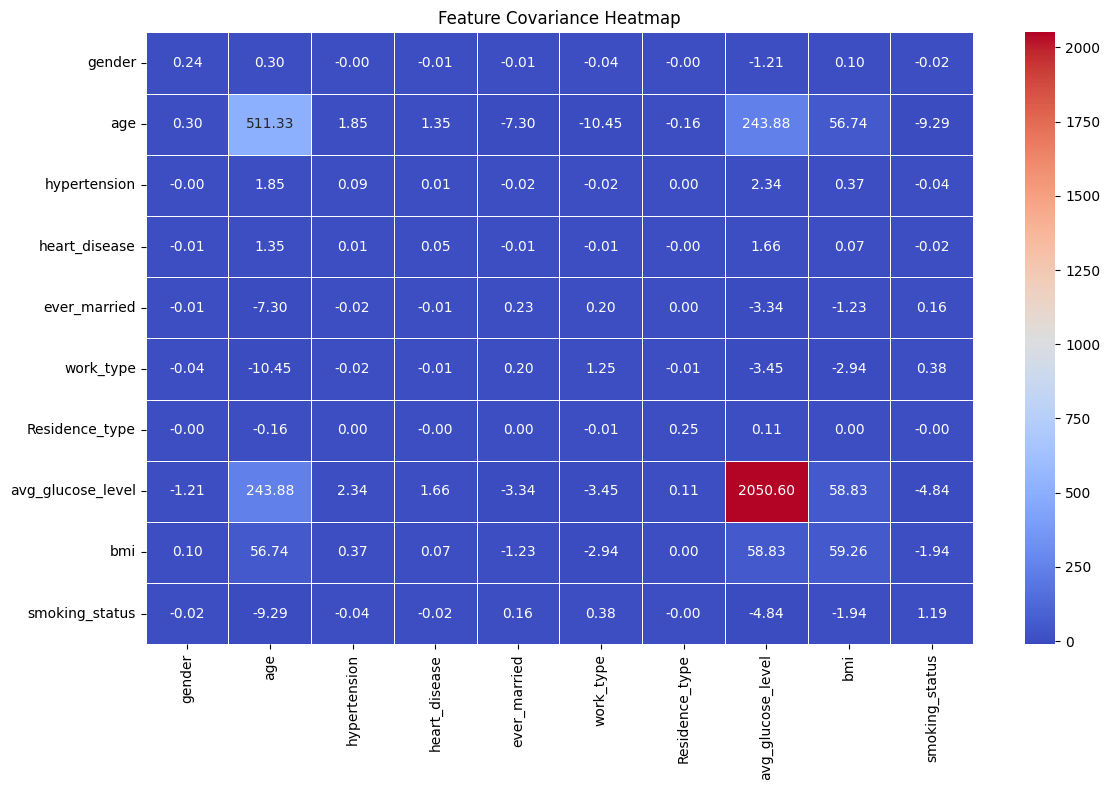

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the processed dataset is available
# You may need to re-run the preprocessing function if df is not defined in this scope
dataframe, _ = processingdata()  # Re-calls the preprocessing to get a fresh cleaned DataFrame

# Drop identifier and target columns to isolate features only
features_only = dataframe.drop(columns=['id', 'stroke'])

# Compute the covariance matrix for the numerical features
feature_covariance = features_only.cov()

# Visualize the covariance matrix using a heatmap for easy interpretation
plt.figure(figsize=(12, 8))
sns.heatmap(feature_covariance, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Covariance Heatmap')
plt.tight_layout()
plt.show()


In [22]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Since this is a binary classification problem, we reduce to 1 linear component
lda_transformer = LinearDiscriminantAnalysis(n_components=1)

# and simultaneously transform the feature space
X_train_reduced = lda_transformer.fit_transform(X_train, y_train)

# Use the fitted LDA model to transform the test data into the same reduced space
X_test_reduced = lda_transformer.transform(X_test)


In [23]:
# Create an instance of the custom logistic regression model
# This model will be trained on the LDA-reduced feature set
lda_based_model = MyLogisticModel(lr=0.01, iterations=1000)

# Train the model using LDA-transformed training features and corresponding labels
lda_based_model.train(X_train_reduced, y_train.to_numpy())

# Generate predictions using the test data transformed by LDA
lda_predictions = lda_based_model.classify(X_test_reduced)

# Evaluate the model's performance using accuracy and detailed classification metrics
print("Accuracy using LDA + Custom Logistic Regression:", accuracy_score(y_test.to_numpy(), lda_predictions))

# Display metrics like precision, recall, and F1-score for each class
print("\nClassification Report for LDA-based Model:\n", classification_report(y_test.to_numpy(), lda_predictions))


Accuracy using LDA + Custom Logistic Regression: 0.7279843444227005

Classification Report for LDA-based Model:
               precision    recall  f1-score   support

           0       0.98      0.73      0.83       960
           1       0.15      0.76      0.25        62

    accuracy                           0.73      1022
   macro avg       0.57      0.74      0.54      1022
weighted avg       0.93      0.73      0.80      1022



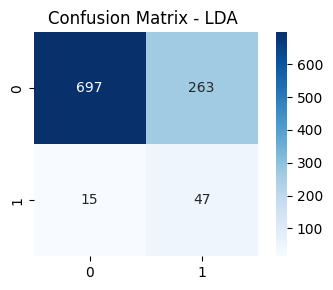

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Convert to DataFrame for labeling (optional but helpful for seaborn)
#X_lda_df = pd.DataFrame(X_train_lda, columns=["LDA_Component1"])

conf_matrix = confusion_matrix(y_test.to_numpy(), lda_predictions)

# Step 6: Plot confusion matrix using heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt="d", square=True)
plt.title("Confusion Matrix - LDA ")
plt.tight_layout()
plt.show()
